# Importing Libraries and Defining Features

In [373]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.api as sm
import scipy.stats
from linearmodels import PanelOLS


West_EU = ["Germany", "France", "Belgium", "Netherlands", "Luxembourg", "Austria", "Ireland"]
#West_EU = ["Germany", "France", "Belgium", "Netherlands", "Austria"]
East_EU = ["Bulgaria", "Hungary", "Czechia", "Poland", "Romania", "Slovakia"]
South_EU = ["Spain", "Slovenia", "Portugal", "Italy", "Croatia", "Greece"]
Nord_EU = ["Denmark", "Sweden", "Norway", "Finland", "Estonia", "Latvia", "Lithuania"]

ALL_COUNTRIES = West_EU + East_EU + South_EU + Nord_EU

FEATURES = ["population_Mio", "gdp_per_capita_USD", "gdp_growth_rate_Percent", "hdd_DegreesC"]
FEATURES_ln = ["ln_pop", "ln_gdp_pc", "ln_hdd"]

TARGET = ["Total_Heat_TJ"]
TARGET_ln = ["ln_total_heat"]

# Data Preparation

## Preparing the data on share of technologies in Total Heat

In [374]:
nrg_d_hhq = pd.read_csv("Heat Pump/eurostat_nrg_d_hhq.csv")

# selecting only the wanted columns and renaming name
nrg_d_hhq = nrg_d_hhq[["nrg_bal", "Standard international energy product classification (SIEC)", "Geopolitical entity (reporting)", "TIME_PERIOD", "OBS_VALUE"]]
nrg_d_hhq= nrg_d_hhq.rename(columns={
    "TIME_PERIOD": "year",
    "Geopolitical entity (reporting)": "country",
    "OBS_VALUE": "Energy_TJ",
    "Standard international energy product classification (SIEC)": "carrier"
})  

# sum of both space heating and water heating
nrg_d_hhq_heating = (
    nrg_d_hhq
    .groupby(["carrier", "country", "year"], as_index=False)["Energy_TJ"]
    .sum()
)

# Get the "Total" value for each country-year
totals = (
    nrg_d_hhq_heating[nrg_d_hhq_heating["carrier"] == "Total"]
    [["country", "year", "Energy_TJ"]]
    .rename(columns={"Energy_TJ": "Total_Energy_TJ"})
)

# Merge totals back to the main dataframe
nrg_d_hhq_heating = nrg_d_hhq_heating.merge(
    totals,
    on=["country", "year"],
    how="left"
)

# Compute share
nrg_d_hhq_heating["share_pu"] = (
    nrg_d_hhq_heating["Energy_TJ"] /
    nrg_d_hhq_heating["Total_Energy_TJ"]
)

#nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.carrier=="Total") & (nrg_d_hhq_heating.country=="Norway")]
nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.country=="France") & (nrg_d_hhq_heating.year==2024)]

,carrier,country,year,Energy_TJ,Total_Energy_TJ,share_pu
132,Ambient heat (heat pumps),France,2024,174289.222,1200657.665,0.145161
515,Gas oil and diesel oil,France,2024,106288.558,1200657.665,0.088525
898,Liquefied petroleum gases,France,2024,14465.872,1200657.665,0.012048
1281,Natural gas,France,2024,334150.240,1200657.665,0.278306
1664,Oil and petroleum products,France,2024,127649.748,1200657.665,0.106317
2047,Total,France,2024,1200657.665,1200657.665,1.000000


In [375]:
# saving the historical data of heat pump heat consumption to be used for historical electricity demand of them.
hist_hp_demand = nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.carrier=="Ambient heat (heat pumps)")]
hist_hp_demand.to_csv("Data - raw/prepared_data/hist_hp_heat_demand.csv")

In [376]:
# calculating average share of each carrier over 2010 to 2024
carrier_shares = nrg_d_hhq_heating.groupby(["country", "carrier"], as_index=False)["share_pu"].mean()
carrier_shares = carrier_shares[(carrier_shares.carrier!="Total")
                                & (carrier_shares.carrier!="Gas oil and diesel oil")
                                & (carrier_shares.carrier!="Liquefied petroleum gases")
                                ]
carrier_shares[carrier_shares.country=="Norway"]#.sum()

,country,carrier,share_pu
108,Norway,Ambient heat (heat pumps),0.123564
111,Norway,Natural gas,0.000788
112,Norway,Oil and petroleum products,0.021572


In [377]:
# caculating the maximum available share of Heat pumps per country
max_hp_share = carrier_shares.groupby(["country"])["share_pu"].sum()
max_hp_share

country
Austria        0.440016
Belgium        0.829804
Bulgaria       0.040029
Croatia        0.297118
Czechia        0.299351
Denmark        0.253124
Estonia        0.062948
Finland        0.160295
France         0.554859
Germany        0.713357
Greece         0.553204
Hungary        0.533975
Ireland        0.767110
Italy          0.683067
Latvia         0.104440
Lithuania      0.176030
Luxembourg     0.896873
Netherlands    0.879446
Norway         0.145923
Poland         0.212406
Portugal       0.495350
Romania        0.364833
Slovakia       0.548471
Slovenia       0.306233
Spain          0.637404
Sweden         0.032608
Name: share_pu, dtype: float64

In [378]:
# Handling the Assumptions of Norway and Finnland:
# The mean value of max available hp_share is less then the hp share in 2024. Therefore I will use the maximum value
# the hp_share had during the period of 2010 to 2024, plus the oil and gas share in the corresponding year
No_Fin_carrier_share = nrg_d_hhq_heating[
    (nrg_d_hhq_heating.country.isin(["Norway", "Finland"]))
    & (nrg_d_hhq_heating.carrier.isin(["Ambient heat (heat pumps)", "Natural gas", "Oil and petroleum products"]))
]

No_Fin_carrier_share = No_Fin_carrier_share[["carrier", "country", "year", "share_pu"]]

No_Fin_carrier_share = No_Fin_carrier_share.pivot(index={"year", "country"}, columns="carrier", values="share_pu")


#max_hp_share.Norway = No_Fin_carrier_share.loc["Norway", 2023].sum()
max_hp_share.Norway = No_Fin_carrier_share.loc[2023, "Norway"].sum()
#max_hp_share.Finland = No_Fin_carrier_share.loc["Finland", 2023].sum()
max_hp_share.Finland = No_Fin_carrier_share.loc[2023, "Finland"].sum()

max_hp_share

country
Austria        0.440016
Belgium        0.829804
Bulgaria       0.040029
Croatia        0.297118
Czechia        0.299351
Denmark        0.253124
Estonia        0.062948
Finland        0.181114
France         0.554859
Germany        0.713357
Greece         0.553204
Hungary        0.533975
Ireland        0.767110
Italy          0.683067
Latvia         0.104440
Lithuania      0.176030
Luxembourg     0.896873
Netherlands    0.879446
Norway         0.170314
Poland         0.212406
Portugal       0.495350
Romania        0.364833
Slovakia       0.548471
Slovenia       0.306233
Spain          0.637404
Sweden         0.032608
Name: share_pu, dtype: float64

In [379]:
# seperating the target values of the model in heat_demand
heat_demand = nrg_d_hhq_heating.loc[(nrg_d_hhq_heating.carrier=="Total")]
heat_demand = heat_demand[["country", "year", "Total_Energy_TJ"]]
heat_demand = heat_demand.rename(columns=
                                 {"Total_Energy_TJ": "Total_Heat_TJ"}
                                 )

# Norway value for 2024 is missing in csv file! so it is filled manually:
# Total, space heating: 131173.441 & water heating: 25183.669
new_row = pd.DataFrame({
    "country": ["Norway"],
    "year": [2024],
    "Total_Heat_TJ": [131173.441 + 25183.669]
})
heat_demand = pd.concat([heat_demand, new_row], ignore_index=True)


#heat_demand[(heat_demand.country=="Norway") & (heat_demand.year==2024)]

heat_demand

,country,year,Total_Heat_TJ
0,Austria,2010,251955.007
1,Austria,2011,232075.458
2,Austria,2012,237258.529
3,Austria,2013,247036.708
4,Austria,2014,221009.108
...,...,...,...
379,Sweden,2021,223346.499
380,Sweden,2022,208850.634
381,Sweden,2023,214675.124
382,Sweden,2024,210038.766


## Importing Panel Data (Features)

In [380]:
# importing panel data for population, gdp per capita and HDD
panel = pd.read_csv("Data - raw/prepared_data/panel_transformed.csv")
panel = panel[["year", "country"] + FEATURES_ln]

In [381]:
# creating the training set of histroical data
hist = panel[panel.year <= 2024]
hist = hist.merge(heat_demand, on=["year", "country"], how="left")
hist = hist[hist.year >= 2010]

# missing values: filling forwardly
hist = hist.sort_values(["country", "year"])
hist["Total_Heat_TJ"] = (
    hist.groupby("country")["Total_Heat_TJ"]
    .ffill()
)

hist = hist.set_index(["country", "year"])

hist#[hist.country=="Lithuania"]

ln_pop  ln_gdp_pc    ln_hdd  Total_Heat_TJ
country year                                              
Austria 2010  2.235552  10.995348  8.272347     251955.007
        2011  2.238064  11.022102  8.074398     232075.458
        2012  2.241573  11.024084  8.146563     237258.529
        2013  2.246212  11.015196  8.152612     247036.708
        2014  2.252111  11.016199  8.149901     221009.108
...                ...        ...       ...            ...
Sweden  2020  2.427241  10.994286  8.442473     209761.269
        2021  2.431795  11.044091  8.447937     223346.499
        2022  2.438193  11.048954  8.297176     208850.634
        2023  2.444220  11.043282  8.248988     214675.124
        2024  2.446833  11.044723  8.373914     210038.766

[390 rows x 4 columns]

In [382]:
# Replacing values of Zero with NaN and then fill them backward for each country!
# replace 0 with NaN
hist["Total_Heat_TJ"] = (
    hist["Total_Heat_TJ"]
    .replace(0, np.nan)
)

# fill using next available year within each country
hist["Total_Heat_TJ"] = (
    hist.groupby(level="country")["Total_Heat_TJ"]
    .bfill()
)

hist["ln_total_heat"] = np.log1p(hist['Total_Heat_TJ'])

In [383]:
# preparing the projection input data
proj = panel[panel.year > 2024]

proj = proj.set_index(["country", "year"])

proj

,,ln_pop,ln_gdp_pc,ln_hdd
country,year,,,
Austria,2025,2.322114,11.050321,8.125675
Belgium,2025,2.555947,11.060191,7.648291
Bulgaria,2025,2.006516,10.467513,7.767877
Croatia,2025,1.583987,10.703079,7.495500
Czechia,2025,2.477336,10.797186,7.954813
...,...,...,...,...
Romania,2060,2.852642,11.187993,7.841816
Slovakia,2060,1.766487,11.146595,7.957286
Slovenia,2060,1.114359,11.312611,7.715048


## Plotting Function

In [384]:
def plot_heat_demand(
    hist,
    proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions",      # or "ML_predictions"
    proj_pred_col="Total_Heat_TJ",          # or "Total_Heat_TJ_PanelOLS" / "Total_Heat_TJ_ML"
    countries_list=None,
    title="Heat Demand: Actuals, Model Fit & Projection",
    test_split_year=2020,
):
    """
    Grid plot of heat demand for every country (max 3 columns).

    Parameters
    ----------
    hist            : DataFrame with (country, year) MultiIndex
    proj            : DataFrame with (country, year) MultiIndex
    hist_actual_col : column in hist plotted as solid blue (actuals)
    hist_pred_col   : column in hist plotted as dotted orange (model predictions)
    proj_pred_col   : column in proj plotted as dashed green (projection)
    countries_list  : countries to include (default: all in hist index)
    year            : draw a vertical red dotted line at this year (default: 2020)
    """
    if countries_list is None:
        countries_list = sorted(hist.index.get_level_values("country").unique().tolist())

    n     = len(countries_list)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(15, nrows * 3),
        constrained_layout=True,
    )
    axes_flat = axes.flatten()

    for i, country in enumerate(countries_list):
        ax = axes_flat[i]

        # ── Actual historical values (solid blue) ───────────────────────────
        try:
            actual = hist[hist_actual_col].xs(country, level="country")
            ax.plot(actual.index, actual.values,
                    "-", color="steelblue", lw=1.5, label="Actual")
        except KeyError:
            pass

        # ── Historical model predictions (dotted orange) ────────────────────
        if hist_pred_col in hist.columns:
            try:
                pred = hist[hist_pred_col].xs(country, level="country")
                ax.plot(pred.index, pred.values,
                        ":", color="darkorange", lw=1.8, label=f"Model ({hist_pred_col})")
            except KeyError:
                pass

        # ── Future projection (dashed green) ────────────────────────────────
        if proj_pred_col in proj.columns:
            try:
                fut = proj[proj_pred_col].xs(country, level="country")
                ax.plot(fut.index, fut.values,
                        "--", color="seagreen", lw=1.5, label=f"Projection ({proj_pred_col})")
            except KeyError:
                pass

        # ── Train/test split line (red dotted vertical) ──────────────────────
        #ax.axvline(x=test_split_year, color="red", linestyle=":", lw=1.5, label=f"Test split ({test_split_year})", alpha=0.3)
        if test_split_year is not None:
            ax.axvline(x=test_split_year, color="red", lw=1.0, ls="--", alpha=0.3,
                        label=f"Train/Test split ({test_split_year})" if i == 0 else "_nolegend_")

        ax.set_title(country, fontsize=9, fontweight="bold")
        ax.set_ylabel("Heat Consumption (TJ)", fontsize=7)
        ax.tick_params(axis="both", labelsize=7)
        ax.set_ylim(bottom=0)

    # Hide any unused subplot slots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    # Shared legend above the grid
    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=10,
               frameon=True, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle(title, fontsize=12, fontweight="bold", y=1.04)

    #plt.savefig("heat_demand_forecast.png", dpi=120, bbox_inches="tight")
    #plt.show()
    return None#fig

# ── Call with PanelOLS predictions ───────────────────────────────────────────
"""plot_heat_demand(
    hist=hist,
    proj=proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions",      # column added in the prediction cell above
    proj_pred_col="Total_Heat_TJ",          # change to "Total_Heat_TJ_ML" when ready
)"""

# ── Example: swap in ML predictions once available ───────────────────────────
# plot_heat_demand(hist, proj, hist_pred_col="ML_predictions", proj_pred_col="Total_Heat_TJ_ML")

'plot_heat_demand(\n    hist=hist,\n    proj=proj,\n    hist_actual_col="Total_Heat_TJ",\n    hist_pred_col="panel_predictions",      # column added in the prediction cell above\n    proj_pred_col="Total_Heat_TJ",          # change to "Total_Heat_TJ_ML" when ready\n)'

## Usefull Area BSO

EU Building Stock Observatory https://energy.ec.europa.eu/topics/energy-efficiency/energy-performance-buildings/eu-building-stock-observatory_en

containing the data of how much usefull floor area is available in each country, and also the share of buildings for each construction year. 
BSO was last updated in May 2026.
The state of data is for year 2020!!

it does not contain the data of Norway

In [385]:
bso = pd.read_excel("Heat Pump/heat_pumps.xlsx", sheet_name="heat_spec_distribution")
bso = bso[:27] # keeping only relevant data
bso = bso[bso.Country.isin(ALL_COUNTRIES)]
bso = bso.set_index("Country")

bso

,gesamtfläche_m2,anteil 0-1945,anteil 1946-1969,anteil 1970-1979,anteil 1980-1989,anteil 1990-1999,anteil 2000-2010,anteil 2011-now
Country,,,,,,,,
Austria,645587790,0.19771,0.271854,0.154544,0.1282,0.136963,0.084131,0.026598
Belgium,922861673,0.410637,0.194266,0.099431,0.092264,0.082534,0.08753,0.033339
Bulgaria,411076575,0.207428,0.22726,0.140852,0.135621,0.113095,0.109924,0.065821
Croatia,226678535,0.128624,0.177176,0.181319,0.143178,0.133073,0.155906,0.080724
Czechia,660472107,0.228278,0.166975,0.134261,0.1465,0.131063,0.131308,0.061616
Denmark,485517559,0.177971,0.174229,0.177836,0.12541,0.119999,0.135124,0.089429
Estonia,44472579,0.267661,0.183905,0.108299,0.103433,0.128461,0.120436,0.087805
Finland,516777934,0.140544,0.232487,0.152647,0.192006,0.118892,0.137784,0.02564
France,4129205964,0.241548,0.126738,0.130624,0.145342,0.112721,0.140145,0.102881


# Model

In [386]:
hist

ln_pop  ln_gdp_pc    ln_hdd  Total_Heat_TJ  ln_total_heat
country year                                                             
Austria 2010  2.235552  10.995348  8.272347     251955.007      12.437010
        2011  2.238064  11.022102  8.074398     232075.458      12.354822
        2012  2.241573  11.024084  8.146563     237258.529      12.376910
        2013  2.246212  11.015196  8.152612     247036.708      12.417296
        2014  2.252111  11.016199  8.149901     221009.108      12.305964
...                ...        ...       ...            ...            ...
Sweden  2020  2.427241  10.994286  8.442473     209761.269      12.253730
        2021  2.431795  11.044091  8.447937     223346.499      12.316484
        2022  2.438193  11.048954  8.297176     208850.634      12.249379
        2023  2.444220  11.043282  8.248988     214675.124      12.276886
        2024  2.446833  11.044723  8.373914     210038.766      12.255052

[390 rows x 5 columns]

In [387]:
#hist_floor = hist.join(bso, on="County")
#hist_floor

## Panel OLS Model

The Model uses ln of input variables (population, gdp_per_capita, HDD) to calculate ln_total_heat

In [388]:
X = hist[FEATURES_ln]
Y = hist[TARGET_ln]

# WHY POOLED OLS (no entity effects)?
#
# For 35-year structural projections we need long-run elasticities:
# "do countries with higher GDP / more people / colder climate use more heat?"
# That relationship is identified from CROSS-COUNTRY (between) variation.
#
# With entity_effects=True the FE estimator uses only WITHIN-COUNTRY,
# year-to-year variation over 15 years. That variation is dominated by HDD
# noise (±10-20 %/yr), while GDP and population change only ~1-2 %/yr —
# the signal is buried. Result: insignificant, wrong-signed β coefficients
# and a negative Between-R², which are useless for long-run forecasting.
#
# The pooled model gives R²=0.9994, all coefficients significant,
# and elasticities that are economically meaningful for projection.

m_panelOLS = PanelOLS(Y, X,
                      entity_effects=True,
                      ).fit(
                          cov_type="clustered",
                          cluster_entity=True,
                      )
m_panelOLS

Dep. Variable:,ln_total_heat,R-squared:,0.0665
Estimator:,PanelOLS,R-squared (Between):,-0.2196
No. Observations:,390,R-squared (Within):,0.0665
Date:,"Sun, Jun 14 2026",R-squared (Overall):,-0.2196
Time:,12:45:17,Log-likelihood,437.50
Cov. Estimator:,Clustered,,
,,F-statistic:,8.5776
Entities:,26,P-value,0.0000
Avg Obs:,15.000,Distribution:,"F(3,361)"
Min Obs:,15.000,,
Max Obs:,15.000,F-statistic (robust):,5.6214


In [389]:
entity_effect = m_panelOLS.estimated_effects.groupby('country')["estimated_effects"].mean()
entity_effect

country
Austria        13.560976
Belgium        13.875803
Bulgaria       12.128415
Croatia        12.171658
Czechia        13.637666
Denmark        12.993960
Estonia        10.906524
Finland        13.039617
France         16.167519
Germany        16.623281
Greece         12.983671
Hungary        13.450351
Ireland        12.527325
Italy          15.874426
Latvia         11.228628
Lithuania      11.533102
Luxembourg     10.309968
Netherlands    14.200820
Norway         12.906525
Poland         15.171785
Portugal       12.247039
Romania        13.857853
Slovakia       12.201235
Slovenia       11.243562
Spain          14.759225
Sweden         13.470687
Name: estimated_effects, dtype: float64

In [390]:
hist

ln_pop  ln_gdp_pc    ln_hdd  Total_Heat_TJ  ln_total_heat
country year                                                             
Austria 2010  2.235552  10.995348  8.272347     251955.007      12.437010
        2011  2.238064  11.022102  8.074398     232075.458      12.354822
        2012  2.241573  11.024084  8.146563     237258.529      12.376910
        2013  2.246212  11.015196  8.152612     247036.708      12.417296
        2014  2.252111  11.016199  8.149901     221009.108      12.305964
...                ...        ...       ...            ...            ...
Sweden  2020  2.427241  10.994286  8.442473     209761.269      12.253730
        2021  2.431795  11.044091  8.447937     223346.499      12.316484
        2022  2.438193  11.048954  8.297176     208850.634      12.249379
        2023  2.444220  11.043282  8.248988     214675.124      12.276886
        2024  2.446833  11.044723  8.373914     210038.766      12.255052

[390 rows x 5 columns]

In [391]:
# In-sample historical fit
hist["panel_predictions"] = m_panelOLS.predict(X)["predictions"]

# Add the entity effect corresponding to each country's rows
hist["panel_predictions"] = (
    hist["panel_predictions"]
    + hist.index.get_level_values("country").map(entity_effect)
)

# calculate the exponential of it, because the model is on "ln"
hist["panel_predictions"] = np.expm1(hist["panel_predictions"])


# Raw model projection 2025–2060
X_proj = proj[FEATURES_ln]
proj["panel_predictions"] = m_panelOLS.predict(X_proj)["predictions"]

# Add the entity effect corresponding to each country's rows
proj["panel_predictions"] = (
    proj["panel_predictions"]
    + proj.index.get_level_values("country").map(entity_effect)
)

proj["panel_predictions"] = np.expm1(proj["panel_predictions"])

In [392]:
hist

ln_pop  ln_gdp_pc    ln_hdd  Total_Heat_TJ  ln_total_heat  \
country year                                                                
Austria 2010  2.235552  10.995348  8.272347     251955.007      12.437010   
        2011  2.238064  11.022102  8.074398     232075.458      12.354822   
        2012  2.241573  11.024084  8.146563     237258.529      12.376910   
        2013  2.246212  11.015196  8.152612     247036.708      12.417296   
        2014  2.252111  11.016199  8.149901     221009.108      12.305964   
...                ...        ...       ...            ...            ...   
Sweden  2020  2.427241  10.994286  8.442473     209761.269      12.253730   
        2021  2.431795  11.044091  8.447937     223346.499      12.316484   
        2022  2.438193  11.048954  8.297176     208850.634      12.249379   
        2023  2.444220  11.043282  8.248988     214675.124      12.276886   
        2024  2.446833  11.044723  8.373914     210038.766      12.255052   

              panel_predictions  
country year                     
Austria 2010      249874.396098  
        2011      241667.333497  
        2012      243804.605863  
        2013      243810.867686  
        2014      243070.369343  
...                         ...  
Sweden  2020      215689.158103  
        2021      214092.435103  
        2022      208724.632248  
        2023      206874.326238  
        2024      210415.191401  

[390 rows x 6 columns]

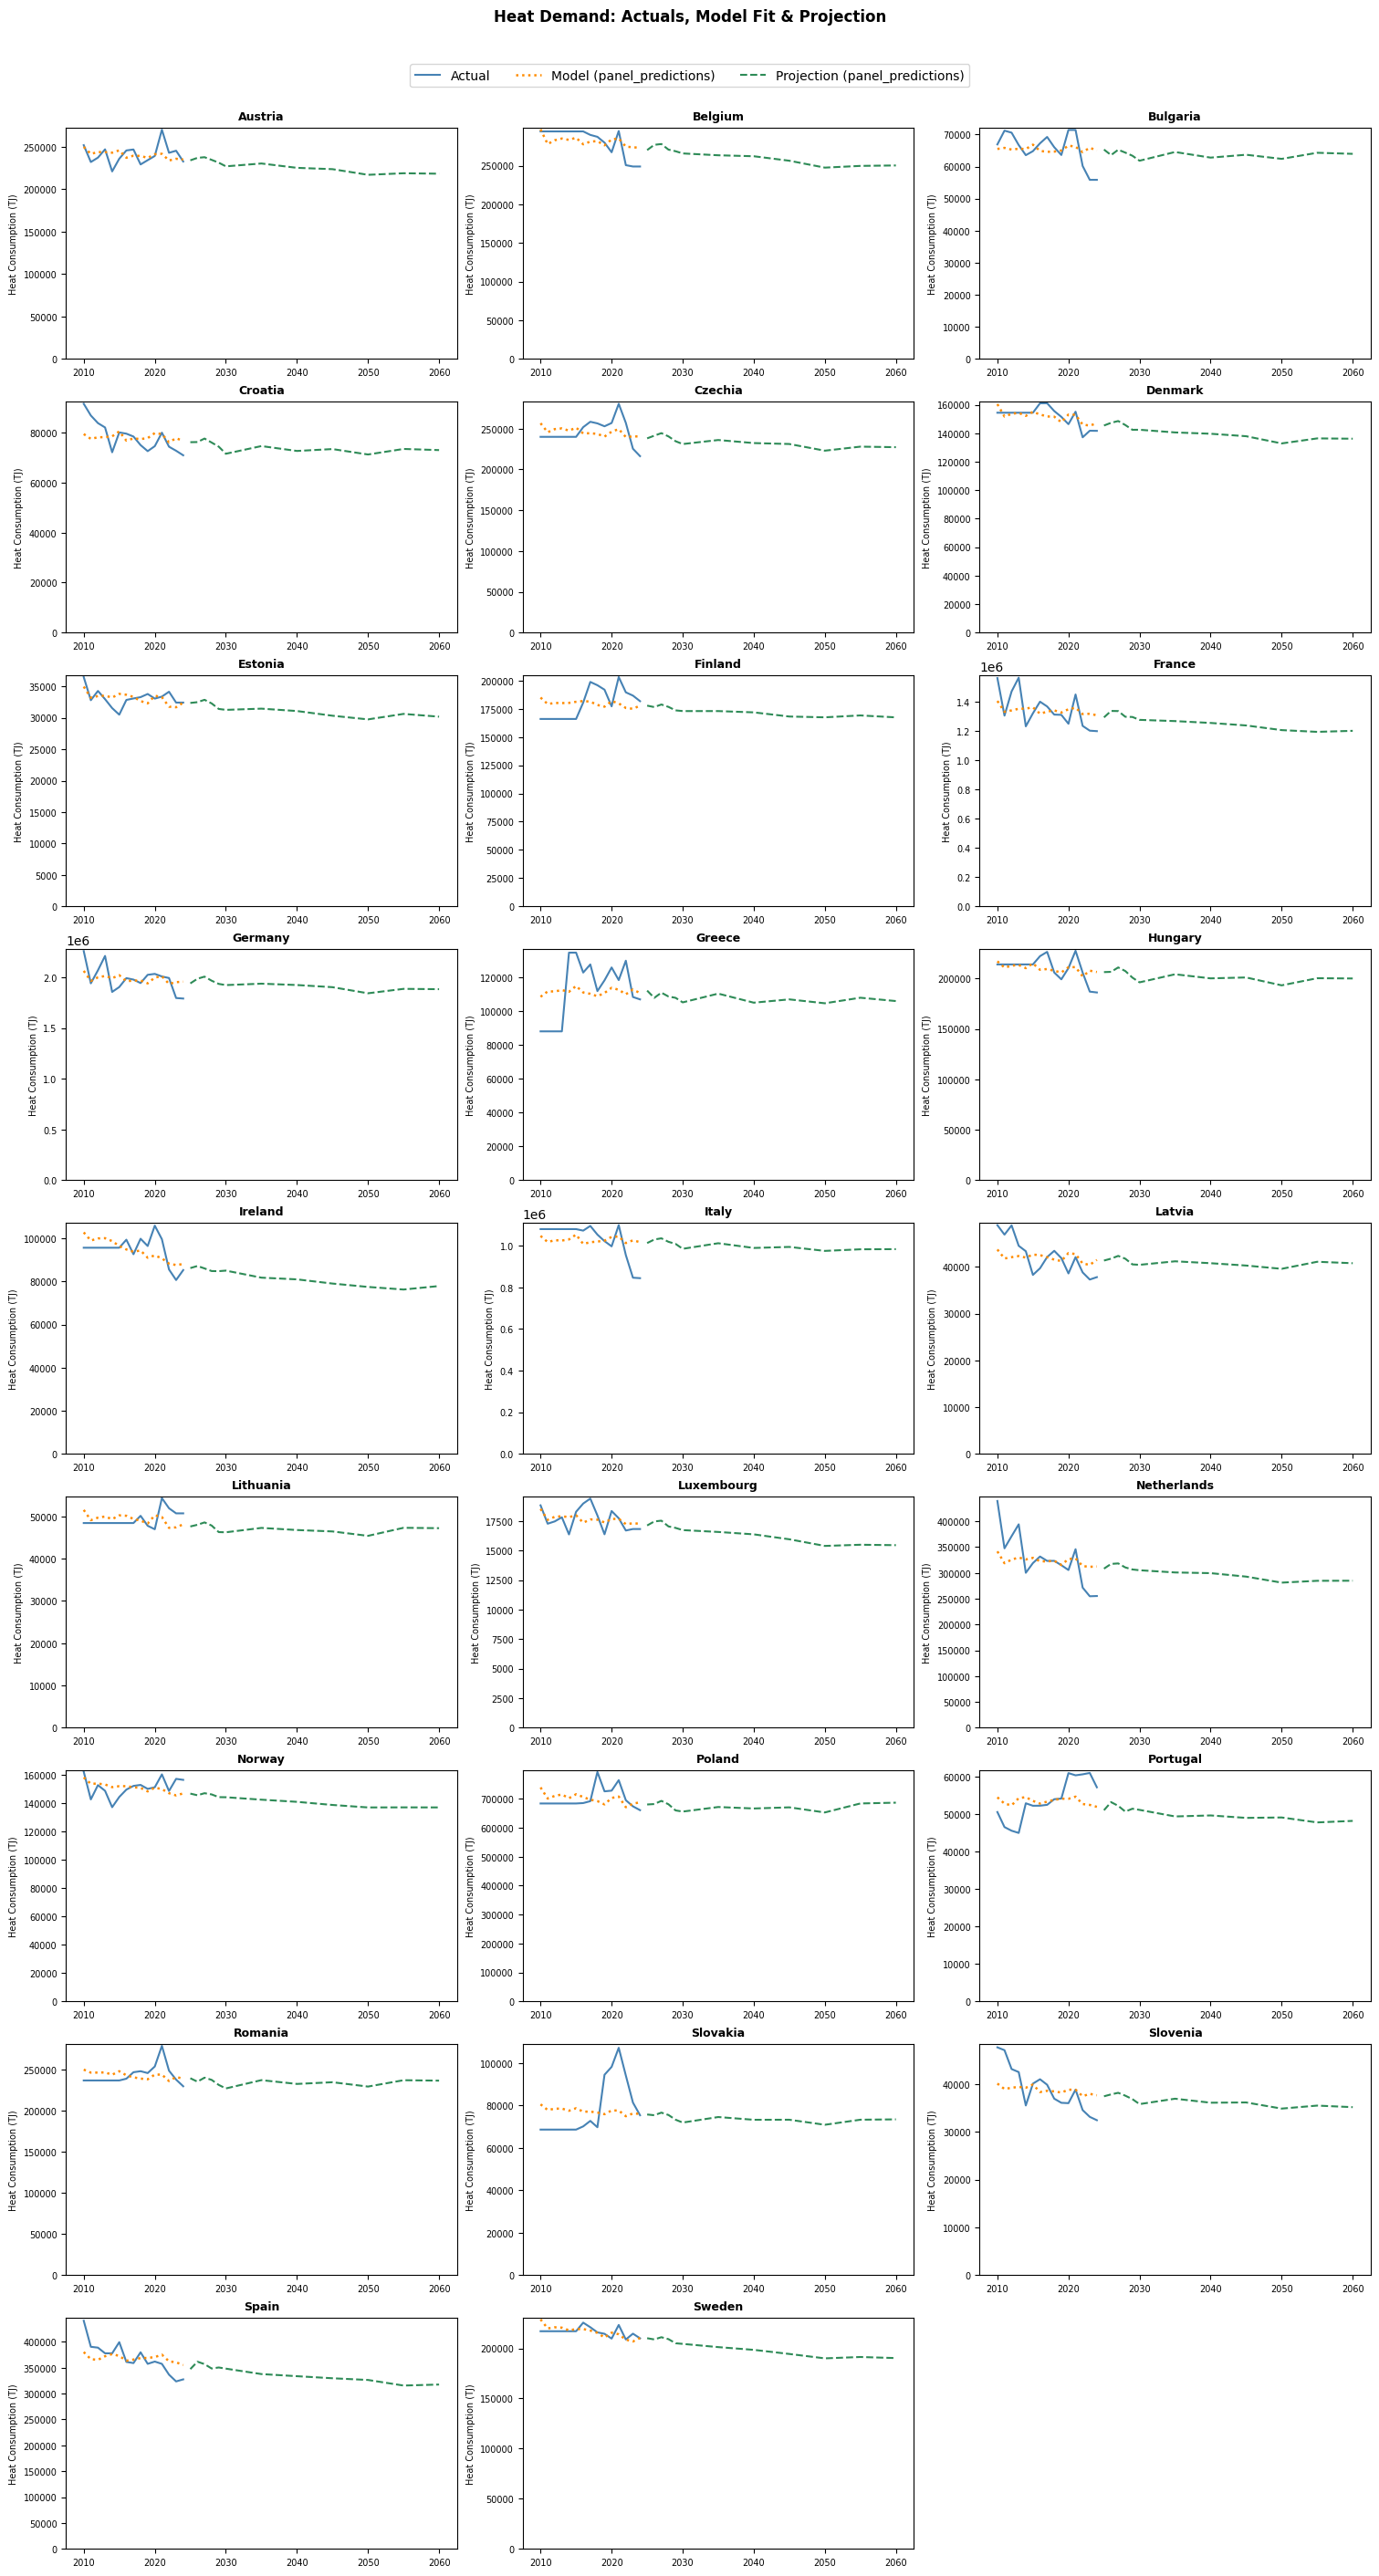

In [393]:
# plotting the results of PanelOLS model
plot_heat_demand(
    hist=hist,
    proj=proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions",      # column added in the prediction cell above
    proj_pred_col="panel_predictions",          # change to "Total_Heat_TJ_ML" when ready
    test_split_year=None
)

## Calibration of Model Results anchored to 2024 actuals

In [394]:
hist.xs("Germany", level="country")#["Total_Heat_TJ"]

,ln_pop,ln_gdp_pc,ln_hdd,Total_Heat_TJ,ln_total_heat,panel_predictions
year,,,,,,
2010,4.416455,10.928883,8.076153,2257836.311,14.629918,2.062767e+06
2011,4.397187,10.966639,7.715717,1939776.104,14.478084,1.963644e+06
2012,4.398489,10.971241,7.844441,2068468.168,14.542319,1.998684e+06
2013,4.400894,10.973594,7.899658,2210032.084,14.608518,2.012223e+06
2014,4.403879,10.990825,7.849409,1855241.170,14.433526,1.990614e+06
2015,4.409125,10.996144,7.969496,1903334.520,14.459118,2.019991e+06
2016,4.420955,11.009954,7.814634,1991289.289,14.504293,1.961390e+06
2017,4.425106,11.035850,7.866234,1976739.098,14.496960,1.966310e+06
2018,4.428342,11.044107,7.889694,1942587.055,14.479532,1.968292e+06


Calibration factors (actual / modeled @ 2024):
country
Netherlands    0.816607
Italy          0.829827
Bulgaria       0.859283
Slovenia       0.861392
Czechia        0.899520
Hungary        0.901767
Latvia         0.911127
Belgium        0.911383
Germany        0.915046
France         0.917264
Spain          0.922169
Croatia        0.925565
Poland         0.960324
Romania        0.960993
Denmark        0.964315
Greece         0.966083
Ireland        0.967974
Luxembourg     0.973845
Austria        0.990458
Slovakia       0.991407
Sweden         0.998211
Estonia        0.999999
Finland        1.022093
Lithuania      1.054079
Norway         1.064907
Portugal       1.100422


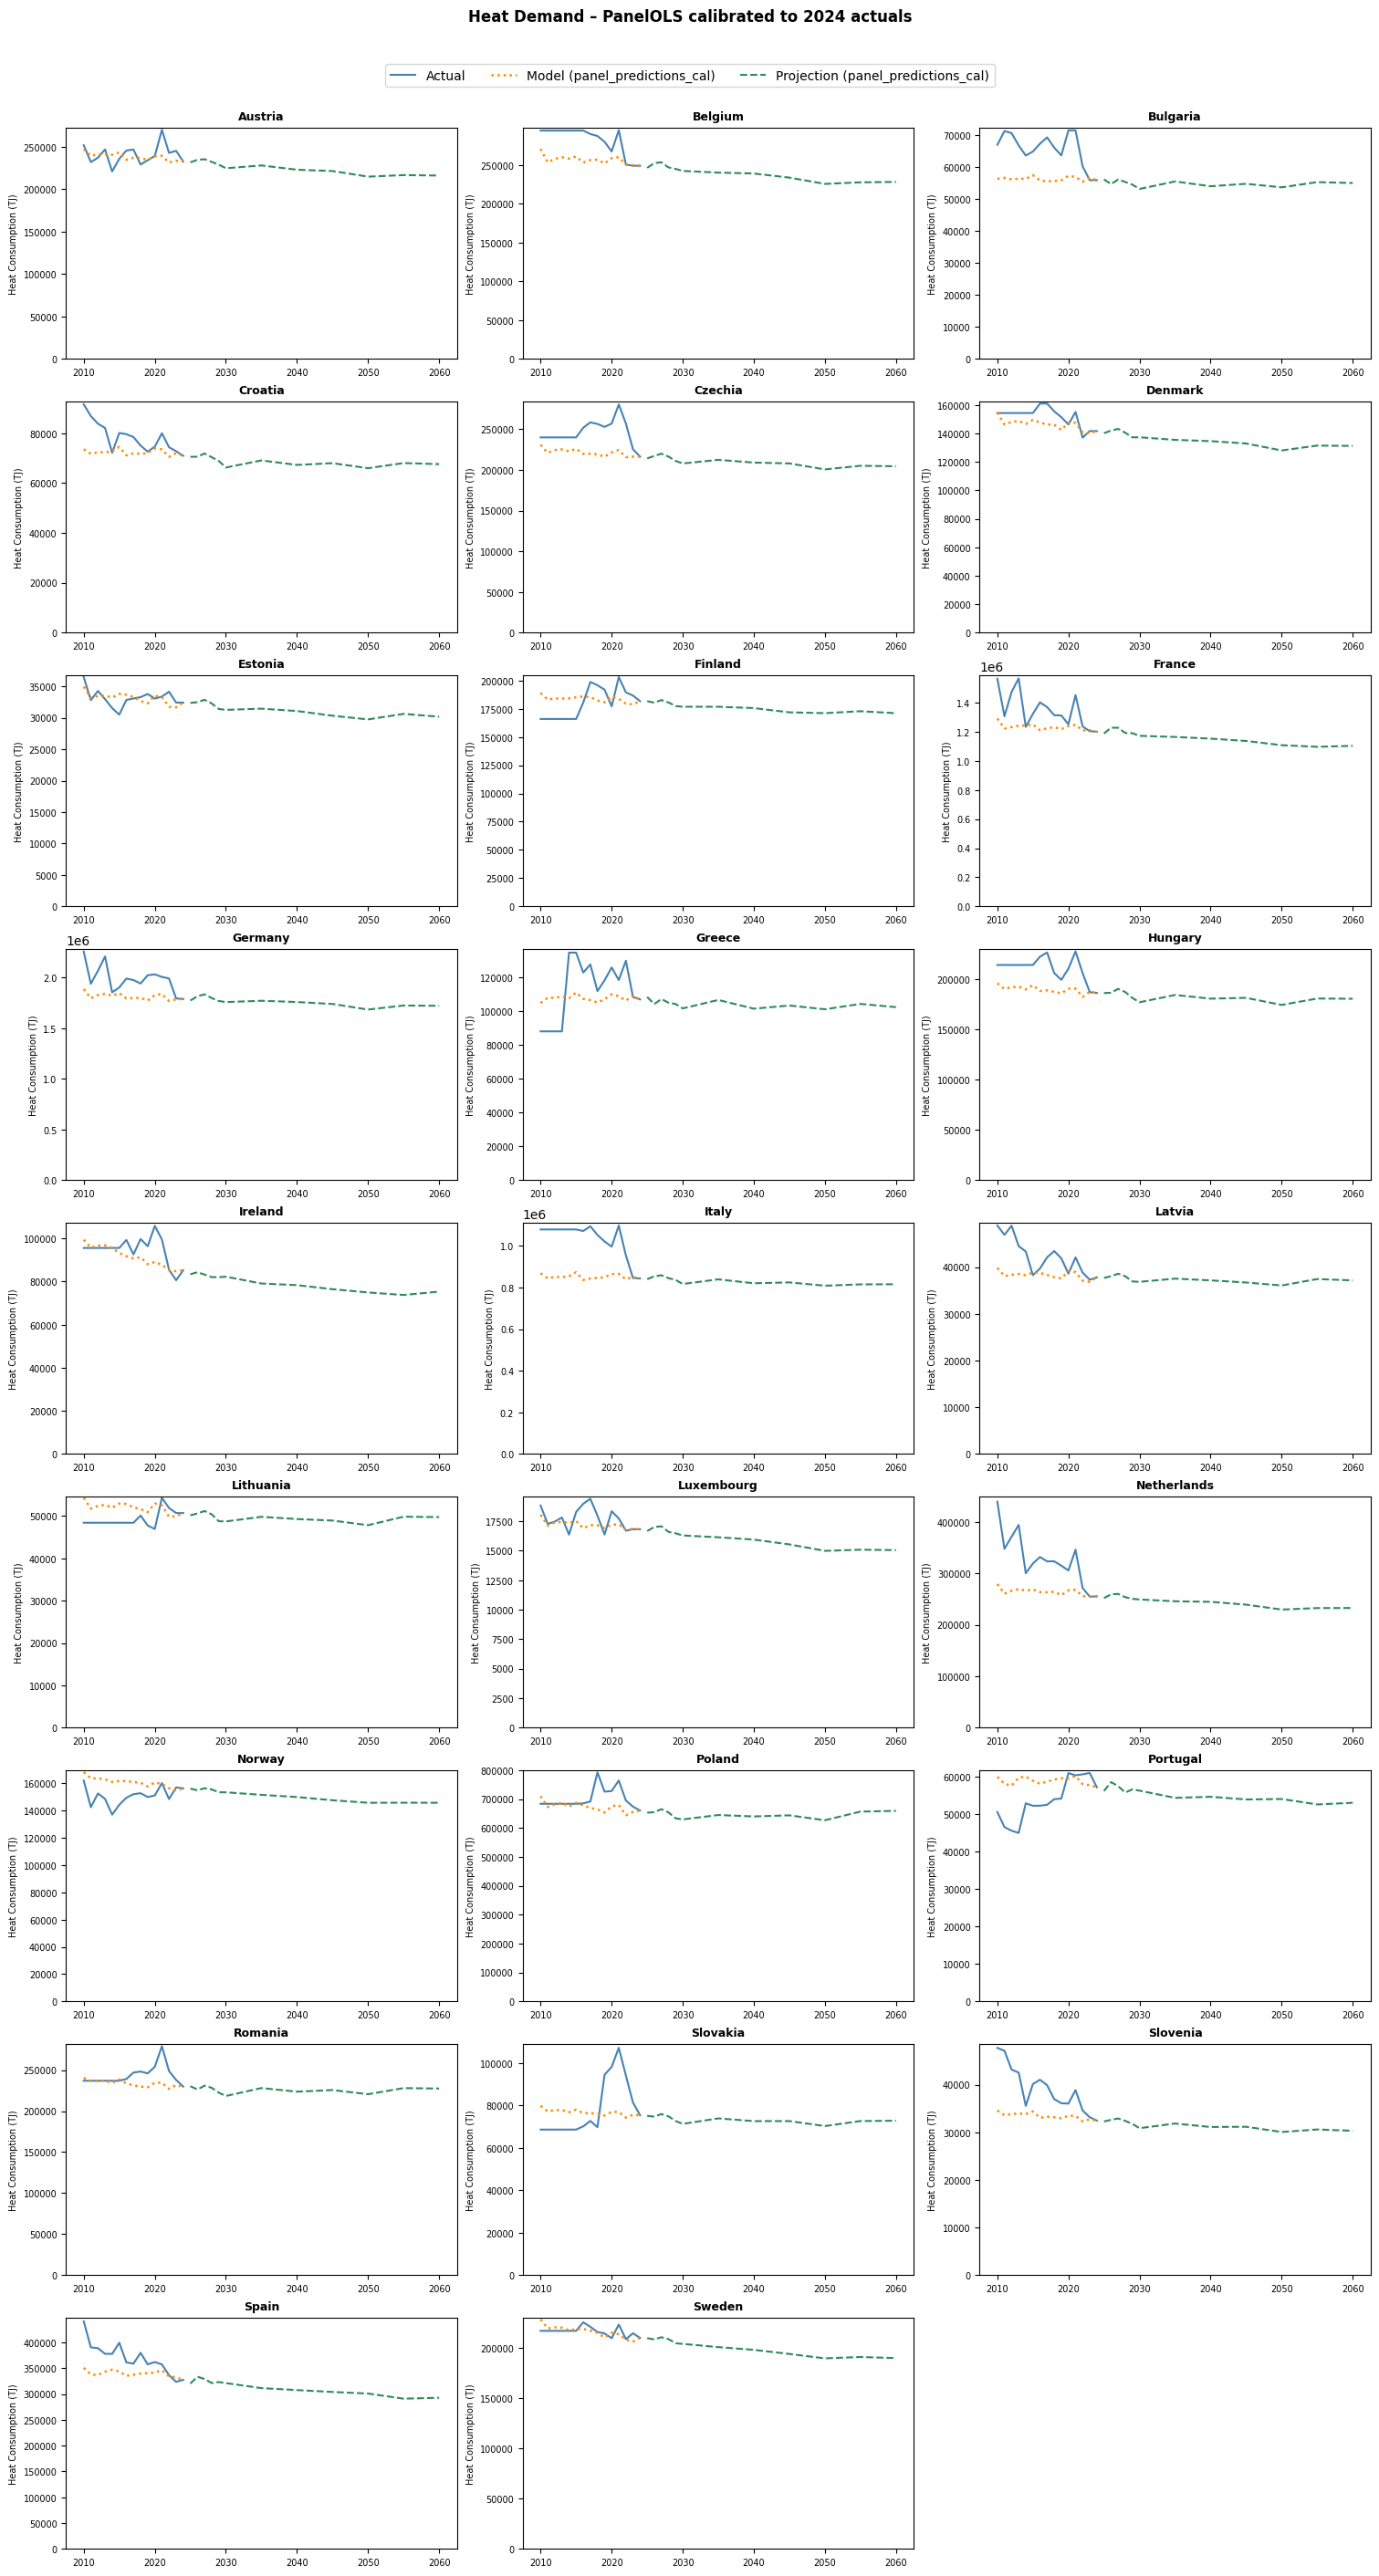

In [395]:
# Calibration factor per country: actual 2024 / modeled 2024
actual_2024  = hist.xs(2024, level="year")["Total_Heat_TJ"]

modeled_2024 = (hist.xs(2024, level="year")["panel_predictions"])

cal_factor_panel = actual_2024 / modeled_2024

# Apply to historical modelled: scale each country's values by its factor
hist["panel_predictions_cal"] = (
    hist["panel_predictions"]
    * hist.index.get_level_values("country").map(cal_factor_panel)
)

# Apply to projection: scale each country's future values by its factor
proj["panel_predictions_cal"] = (
    proj["panel_predictions"]
    * proj.index.get_level_values("country").map(cal_factor_panel)
)

# Compare calibrated vs. uncalibrated for a spot-check
plot_heat_demand(
    hist=hist,
    proj=proj,
    hist_actual_col="Total_Heat_TJ",
    hist_pred_col="panel_predictions_cal",
    proj_pred_col="panel_predictions_cal",
    title="Heat Demand – PanelOLS calibrated to 2024 actuals",
    test_split_year=None,
)

print("Calibration factors (actual / modeled @ 2024):")
print(cal_factor_panel.sort_values().to_string())

# Heat Pump Share Projection

In [396]:
hp_shares_hist = nrg_d_hhq_heating[nrg_d_hhq_heating.carrier == "Ambient heat (heat pumps)"]
hp_shares_hist = hp_shares_hist[["country", "year", "share_pu"]]

# filling the last value for Bulgaria
hp_shares_hist.loc[
    (hp_shares_hist["country"] == "Bulgaria") & 
    (hp_shares_hist["year"] == 2024), 
    "share_pu"
] = 0

hp_shares_hist[hp_shares_hist.country == "Lithuania"]

,country,year,share_pu
223,Lithuania,2010,NaN
224,Lithuania,2011,NaN
225,Lithuania,2012,NaN
226,Lithuania,2013,NaN
227,Lithuania,2014,NaN
228,Lithuania,2015,NaN
229,Lithuania,2016,NaN
230,Lithuania,2017,0.000000
231,Lithuania,2018,0.018591
232,Lithuania,2019,0.020451


In [397]:
# year when max share is reached, and what fraction of max is the target
SCENARIOS = {
    "KKO": {"target_year": 2045, "target_fraction": 1.00},
    "KVE": {"target_year": 2050, "target_fraction": 1.00},
    "VWE": {"target_year": 2060, "target_fraction": 1.00},
    "VNI": {"target_year": 2060, "target_fraction": 0.75},
}

In [398]:
# Building share projections per scenario --> hp_shares_proj
# The development of heat pump shares follows a logistic S-curve (technology diffusion)
PROJ_YEARS = list(range(2025, 2061))

def project_hp_share_scurve(country, scenario_name):
    params          = SCENARIOS[scenario_name]
    target_year     = params["target_year"]
    target_fraction = params["target_fraction"]

    # starting share = last known historical value (2024)
    start_share = (hp_shares_hist
                   .loc[hp_shares_hist["country"] == country, :]
                   .sort_values("year")
                   ["share_pu"]
                   .iloc[-1])

    # target share = fraction of max possible
    end_share = max_hp_share[country] * target_fraction

    # sigmoid parameters: inflection at midpoint, k chosen so curve spans ~5%–95% over the period
    duration  = target_year - 2024
    t_mid     = 2024 + duration / 2
    k         = 6 / duration

    # normalize so progress = 0 at t=2024 and progress = 1 at t=target_year
    sig_start = 1 / (1 + np.exp(-k * (2024        - t_mid)))
    sig_end   = 1 / (1 + np.exp(-k * (target_year - t_mid)))

    rows = []
    for year in PROJ_YEARS:
        if year >= target_year:
            share = end_share
        else:
            sig_t    = 1 / (1 + np.exp(-k * (year - t_mid)))
            progress = (sig_t - sig_start) / (sig_end - sig_start)
            share    = start_share + progress * (end_share - start_share)

        rows.append({"country": country, "year": year,
                     "scenario": scenario_name, "share_pu": share})
    return rows


# build full projection dataframe
all_rows = []
for scenario in SCENARIOS:
    for country in max_hp_share.index:
        all_rows.extend(project_hp_share_scurve(country, scenario))

hp_shares_proj = pd.DataFrame(all_rows)
#print(hp_shares_proj.head(20).to_string())
#print(f"\nShape: {hp_shares_proj.shape}")
hp_shares_proj[hp_shares_proj.country == "Lithuania"]

,country,year,scenario,share_pu
540,Lithuania,2025,KKO,0.085665
541,Lithuania,2026,KKO,0.087582
542,Lithuania,2027,KKO,0.090015
543,Lithuania,2028,KKO,0.093064
544,Lithuania,2029,KKO,0.096816
...,...,...,...,...
3379,Lithuania,2056,VNI,0.129857
3380,Lithuania,2057,VNI,0.130520
3381,Lithuania,2058,VNI,0.131095
3382,Lithuania,2059,VNI,0.131593


In [399]:
# Building share projections per scenario --> hp_shares_proj_linear  (kept for reference)
# The development of heat pump shares are linear
def project_hp_share(country, scenario_name):
    params          = SCENARIOS[scenario_name]
    target_year     = params["target_year"]
    target_fraction = params["target_fraction"]

    # starting share = last known historical value (2024)
    start_share = (hp_shares_hist
                   .loc[hp_shares_hist["country"] == country, :]
                   .sort_values("year")
                   ["share_pu"]
                   .iloc[-1])

    # target share = fraction of max possible
    end_share = max_hp_share[country] * target_fraction

    rows = []
    for year in PROJ_YEARS:
        if year >= target_year:
            share = end_share
        else:
            # linear interpolation between 2024 and target_year
            progress = (year - 2024) / (target_year - 2024)
            share    = start_share + progress * (end_share - start_share)

        rows.append({"country": country, "year": year,
                     "scenario": scenario_name, "share_pu": share})
    return rows


# build full projection dataframe
all_rows = []
for scenario in SCENARIOS:
    for country in max_hp_share.index:
        all_rows.extend(project_hp_share(country, scenario))

hp_shares_proj_linear = pd.DataFrame(all_rows)
#print(hp_shares_proj_linear.head(20).to_string())
#print(f"\nShape: {hp_shares_proj_linear.shape}")
hp_shares_proj_linear[hp_shares_proj_linear.country == "Lithuania"]

,country,year,scenario,share_pu
540,Lithuania,2025,KKO,0.088547
541,Lithuania,2026,KKO,0.092921
542,Lithuania,2027,KKO,0.097295
543,Lithuania,2028,KKO,0.101669
544,Lithuania,2029,KKO,0.106043
...,...,...,...,...
3379,Lithuania,2056,VNI,0.126706
3380,Lithuania,2057,VNI,0.128035
3381,Lithuania,2058,VNI,0.129364
3382,Lithuania,2059,VNI,0.130693


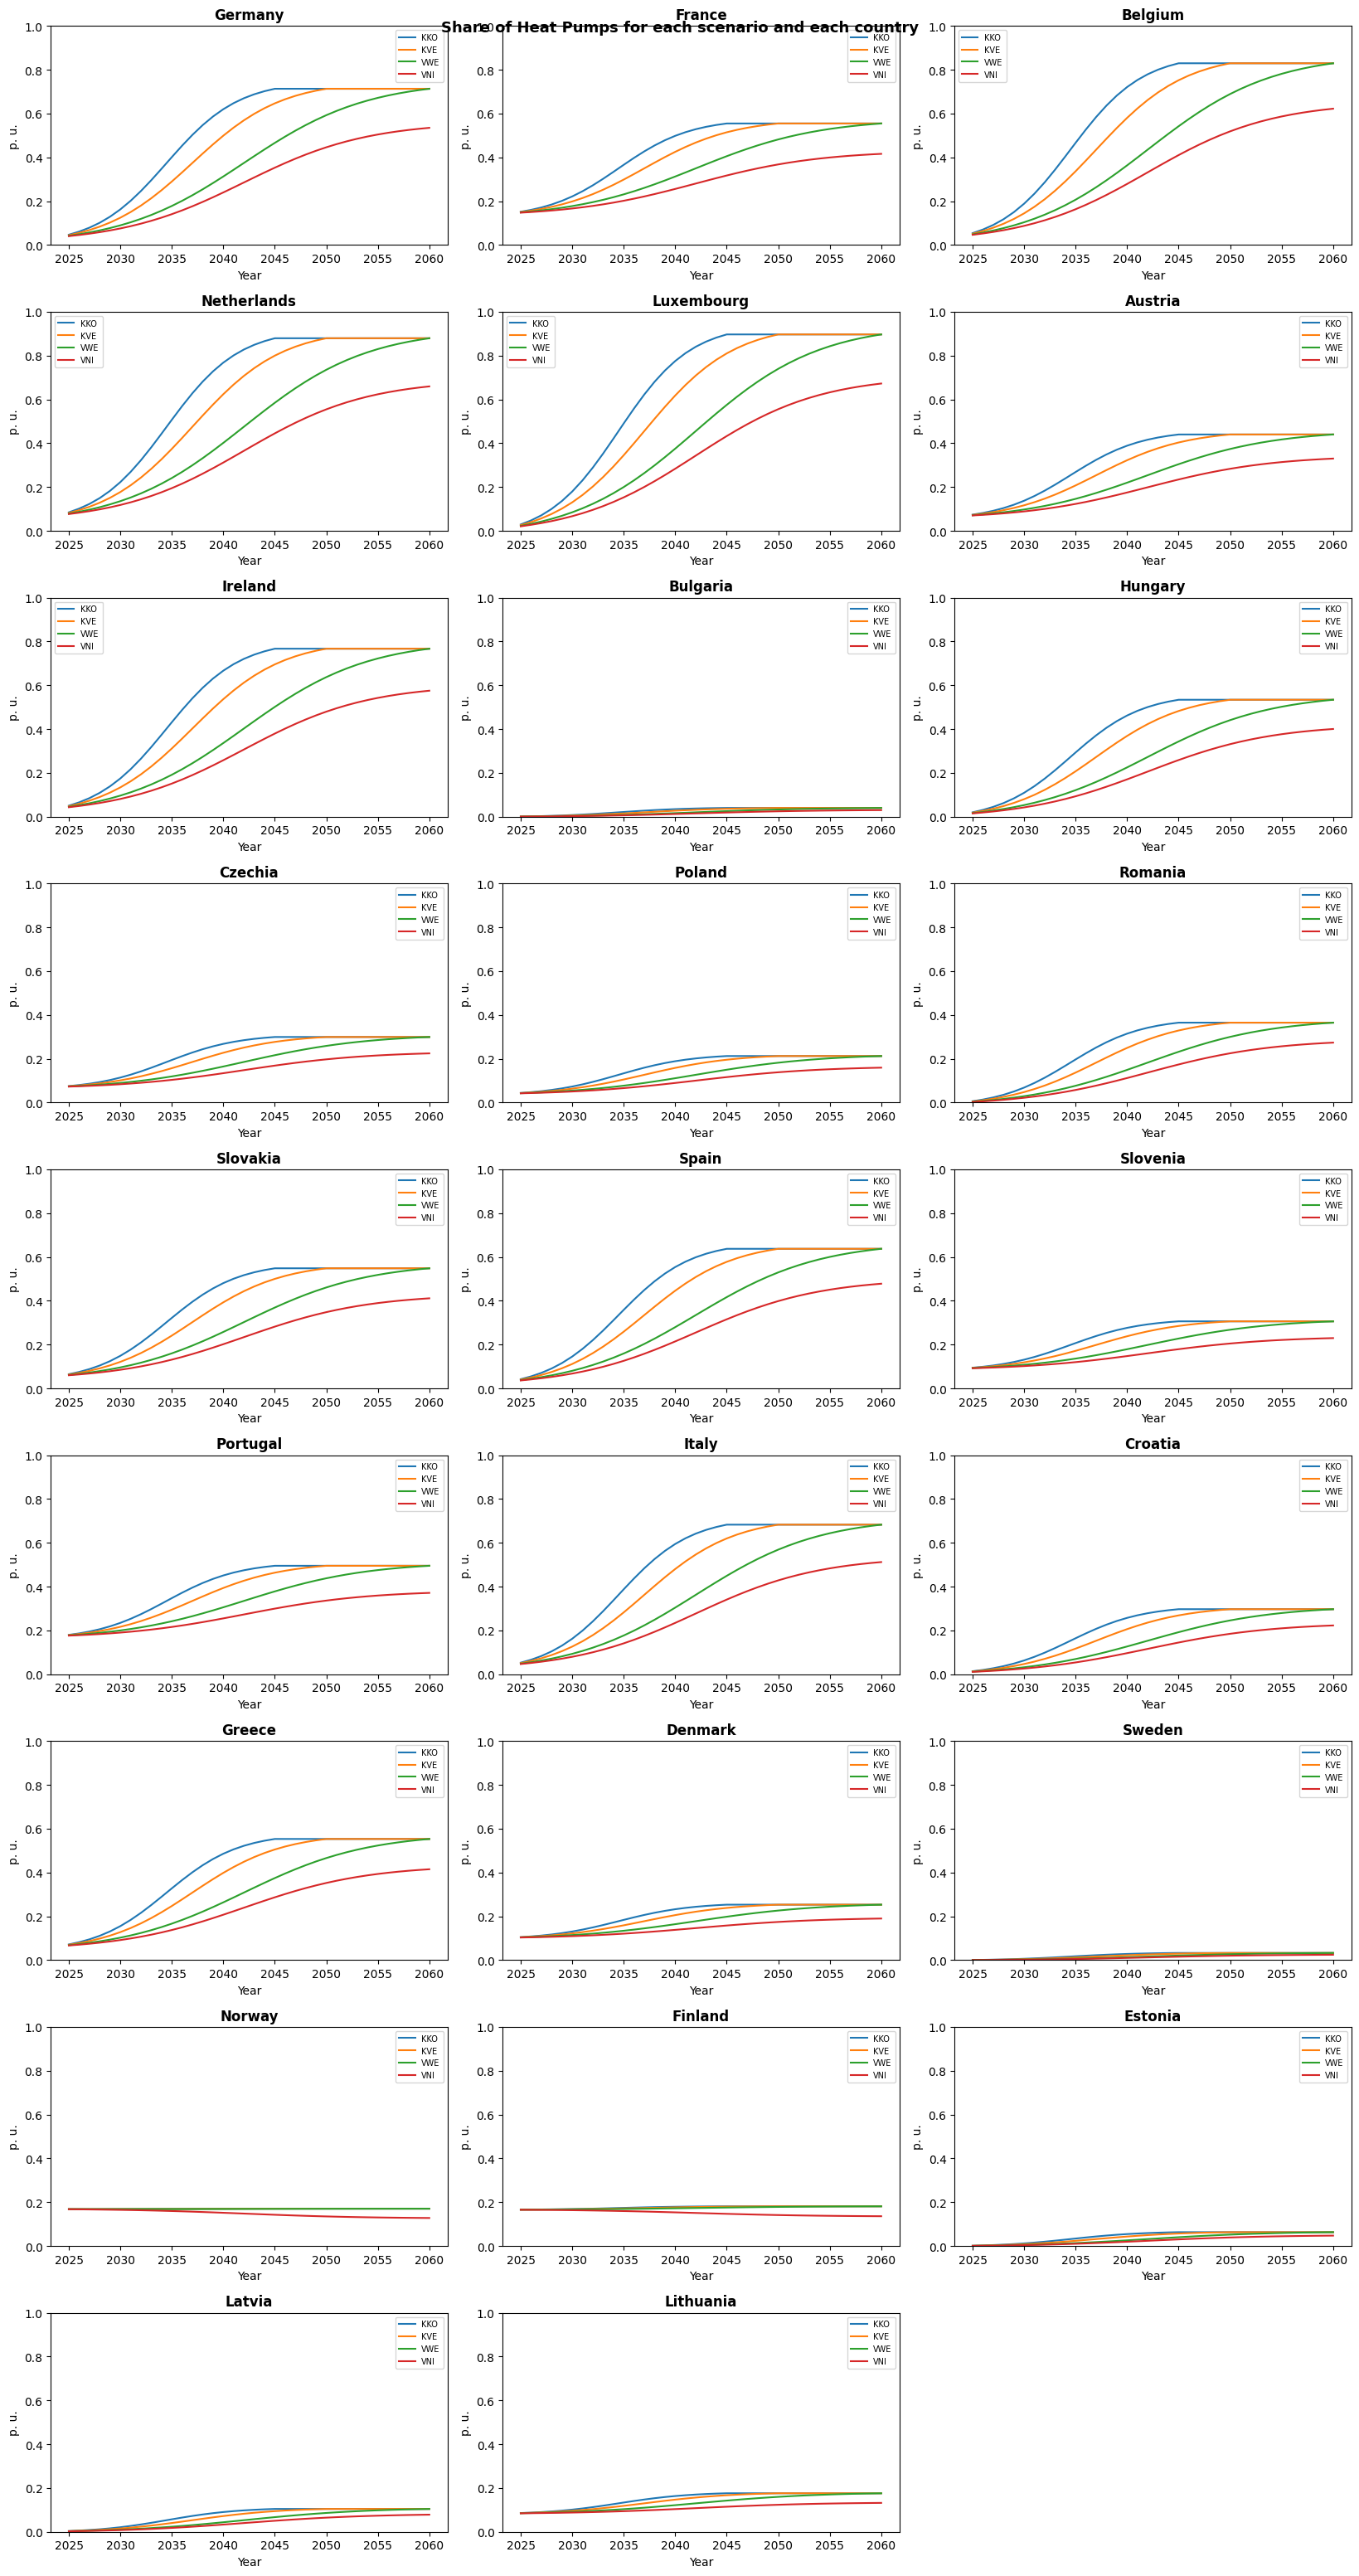

In [400]:
import matplotlib.pyplot as plt
import math

PROJECTION = hp_shares_proj # or hp_shares_proj_linear or hp_shares_proj

n_cols = 3
n_rows = math.ceil(len(ALL_COUNTRIES) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 5.5, n_rows * 3.5))
axes = axes.flatten()

for ax, country in zip(axes, ALL_COUNTRIES):
    for scenario in SCENARIOS:
        d = PROJECTION[
            (PROJECTION["country"]  == country) &
            (PROJECTION["scenario"] == scenario)
        ]
        ax.plot(d["year"], d["share_pu"], label=scenario)

    ax.set_title(country, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("p. u.")
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1.0)

# hide unused subplots
for ax in axes[len(ALL_COUNTRIES):]:
    ax.set_visible(False)

plt.suptitle("Share of Heat Pumps for each scenario and each country",
             fontsize=13, fontweight="bold")
plt.tight_layout()
#plt.savefig("Results/HP_electricity_demand_2025_2060.png", dpi=300)
plt.show()

# Calculation of HP Electricity Demand

In [401]:
proj

,,ln_pop,ln_gdp_pc,ln_hdd,panel_predictions,panel_predictions_cal
country,year,,,,,
Austria,2025,2.322114,11.050321,8.125675,234068.424213,231835.004332
Belgium,2025,2.555947,11.060191,7.648291,270304.145155,246350.731154
Bulgaria,2025,2.006516,10.467513,7.767877,65301.228477,56112.222313
Croatia,2025,1.583987,10.703079,7.495500,76180.182957,70509.708607
Czechia,2025,2.477336,10.797186,7.954813,238170.456119,214239.185756
...,...,...,...,...,...,...
Romania,2060,2.852642,11.187993,7.841816,236771.023049,227535.321470
Slovakia,2060,1.766487,11.146595,7.957286,73429.134719,72798.174881
Slovenia,2060,1.114359,11.312611,7.715048,35187.589163,30310.320387


In [402]:
PROJ_YEARS = [2025, 2026, 2027, 2028, 2029, 2030,
              2035, 2040, 2045, 2050, 2055, 2060]

# COP by country group (from Rivière et al. 2009)
#Southern Europe  & ES, PT, IT, GR, HR, SI & 4.3 
#Western/Central  & FR, DE, AT, BE, NL, LU, IE & 4.0
#Eastern Europe   & PL, CZ, SK, HU, RO, BG & 3.5 
#Nordic/Baltic    & SE, FI, NO, DK, EE, LV, LT & 3.3 

COP_MAP = {
    "Austria": 4.0, "Belgium": 4.0, "Bulgaria": 3.5, "Croatia": 4.3,
    "Czechia": 3.5, "Denmark": 3.3, "Estonia": 3.3, "Finland": 3.3,
    "France": 4.0,  "Germany": 4.0, "Greece": 4.3,  "Hungary": 3.5,
    "Ireland": 4.0, "Italy": 4.0,   "Latvia": 3.3,  "Lithuania": 3.3,
    "Luxembourg": 4.0, "Netherlands": 4.0, "Norway": 3.3, "Poland": 3.5,
    "Portugal": 4.3,   "Romania": 3.5,    "Slovakia": 3.5, "Slovenia": 4.3,
    "Spain": 4.3,      "Sweden": 3.3,
}

# service sector multiplier (HP demand in services on top of residential)
#SERVICE_MULTIPLIER = 1.25
SERVICE_MULTIPLIER = 1

# merge projection shares with total heat demand from ML model
proj = proj.reset_index()
proj_heat = proj[["country", "year", "panel_predictions_cal"]].copy()

hp_demand_proj = hp_shares_proj.merge(proj_heat,
                                       on=["country", "year"],
                                       how="left")

hp_demand_proj["COP"] = hp_demand_proj["country"].map(COP_MAP)

# formula: Demand_HP (TWh) = Heat(TJ) * (1/3600) * share_HP / (COP-1) * 1.25
hp_demand_proj["Demand_HP_TWh"] = (
    hp_demand_proj["panel_predictions_cal"]
    * (1 / 3600)
    * hp_demand_proj["share_pu"]
    #/ (hp_demand_proj["COP"] - 1)
    / (hp_demand_proj["COP"])
    * SERVICE_MULTIPLIER
)

#print(hp_demand_proj.head(20).to_string())
#print(f"\nShape: {hp_demand_proj.shape}")
hp_demand_proj = hp_demand_proj[hp_demand_proj.year.isin(PROJ_YEARS)]
hp_demand_proj = hp_demand_proj.reset_index(drop=True)
hp_demand_proj#[hp_demand_proj.country=="Bulgaria"]

,country,year,scenario,share_pu,panel_predictions_cal,COP,Demand_HP_TWh
0,Austria,2025,KKO,0.073984,231835.004332,4.0,1.191118
1,Austria,2026,KKO,0.081747,234725.058620,4.0,1.332501
2,Austria,2027,KKO,0.091605,235492.978485,4.0,1.498071
3,Austria,2028,KKO,0.103951,232377.771175,4.0,1.677499
4,Austria,2029,KKO,0.119151,229100.667791,4.0,1.895669
...,...,...,...,...,...,...,...
1243,Sweden,2040,VNI,0.009997,198171.827890,3.3,0.166762
1244,Sweden,2045,VNI,0.015537,194089.509903,3.3,0.253831
1245,Sweden,2050,VNI,0.020101,189712.846773,3.3,0.320995
1246,Sweden,2055,VNI,0.022960,191058.833752,3.3,0.369256


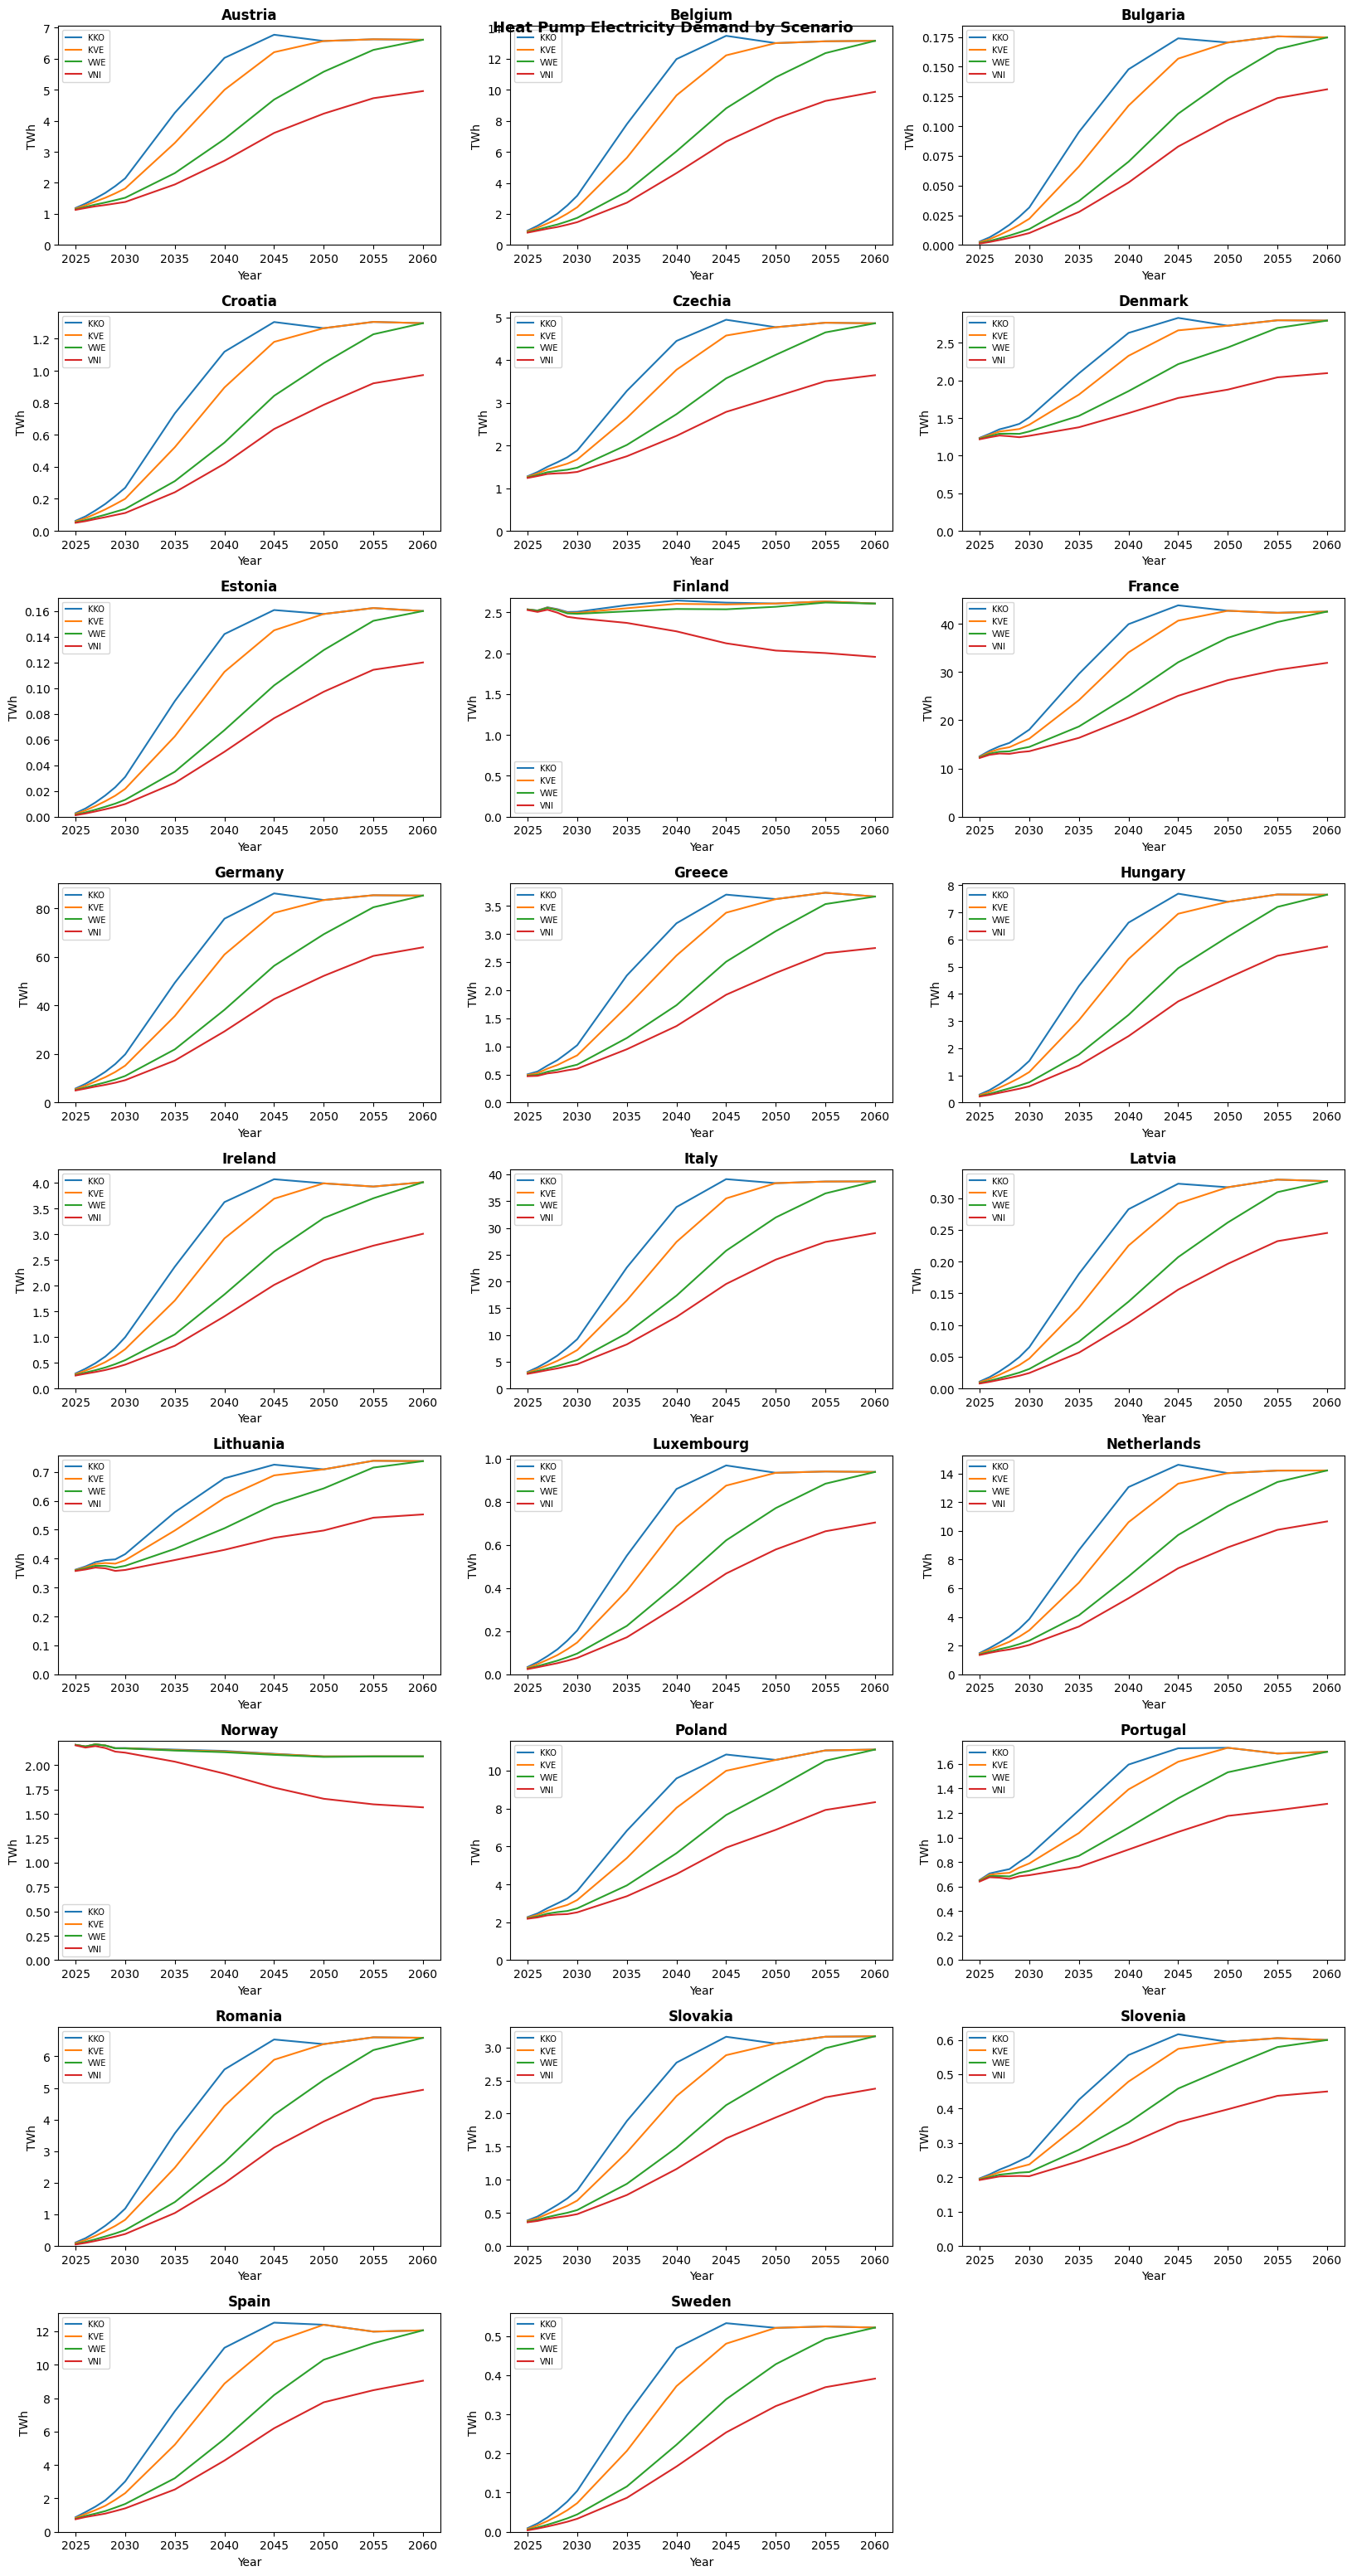

In [403]:
import matplotlib.pyplot as plt
import math

CHECK_COUNTRIES = ALL_COUNTRIES   # or any list of countries
#CHECK_COUNTRIES = ["Bulgaria"]

CHECK_COUNTRIES = sorted(CHECK_COUNTRIES)

n_cols = 3
n_rows = math.ceil(len(CHECK_COUNTRIES) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(n_cols * 5.5, n_rows * 3.5))
axes = axes.flatten()

for ax, country in zip(axes, CHECK_COUNTRIES):
    for scenario in SCENARIOS:
        d = hp_demand_proj[
            (hp_demand_proj["country"]  == country) &
            (hp_demand_proj["scenario"] == scenario)
        ]
        ax.plot(d["year"], d["Demand_HP_TWh"], label=scenario)

    ax.set_title(country, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("TWh")
    ax.legend(fontsize=7)
    ax.set_ylim(0, )

# hide unused subplots
for ax in axes[len(CHECK_COUNTRIES):]:
    ax.set_visible(False)

plt.suptitle("Heat Pump Electricity Demand by Scenario",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("Results/HP_electricity_demand_2025_2060.png", dpi=300)
plt.show()


In [404]:
hp_demand_proj

,country,year,scenario,share_pu,panel_predictions_cal,COP,Demand_HP_TWh
0,Austria,2025,KKO,0.073984,231835.004332,4.0,1.191118
1,Austria,2026,KKO,0.081747,234725.058620,4.0,1.332501
2,Austria,2027,KKO,0.091605,235492.978485,4.0,1.498071
3,Austria,2028,KKO,0.103951,232377.771175,4.0,1.677499
4,Austria,2029,KKO,0.119151,229100.667791,4.0,1.895669
...,...,...,...,...,...,...,...
1243,Sweden,2040,VNI,0.009997,198171.827890,3.3,0.166762
1244,Sweden,2045,VNI,0.015537,194089.509903,3.3,0.253831
1245,Sweden,2050,VNI,0.020101,189712.846773,3.3,0.320995
1246,Sweden,2055,VNI,0.022960,191058.833752,3.3,0.369256
